In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv('spam.csv', encoding='latin-1')

In [3]:
dataset.head(3)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN


In [4]:
dataset.shape

(5572, 5)

## 1. Data Cleaning

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
dataset.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace= True)

In [7]:
dataset.head()


,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
dataset.rename(columns={'v1':'Type', 'v2':'message'}, inplace=True)

In [9]:
dataset.head()

,Type,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
# Missing Values 
dataset.isnull().sum()

Type       0
message    0
dtype: int64

In [11]:
dataset['Type'].unique()

array(['ham', 'spam'], dtype=object)

In [12]:
# Encoding  
from sklearn.preprocessing import LabelEncoder

In [13]:
enc = LabelEncoder()

In [14]:
dataset['Type'] = enc.fit_transform(dataset['Type'])

In [15]:
dataset.head()
# 0 - Ham 
# 1 - Spam 

,Type,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
# Duplicated 
dataset.duplicated().sum()

np.int64(403)

In [17]:
dataset = dataset.drop_duplicates(keep='first')

In [18]:
dataset.duplicated().sum()

np.int64(0)

## 2. Exploratory Data Analysis (EDA)

In [19]:
dataset['Type'].value_counts()

Type
0    4516
1     653
Name: count, dtype: int64

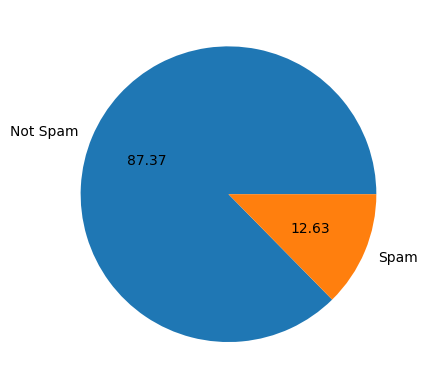

In [20]:
plt.pie(dataset['Type'].value_counts(), labels=['Not Spam', 'Spam'], autopct='%.02f')
plt.show()

In [21]:
import nltk

In [22]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Ragnar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [23]:
dataset['Char_Count'] = dataset['message'].apply(len)

In [24]:
dataset.head()

,Type,message,Char_Count
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [25]:
dataset['Word_Count'] = dataset['message'].apply(lambda x: len(nltk.word_tokenize(x)))

In [26]:
dataset['Sentence_Count'] = dataset['message'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [27]:
dataset.head()

,Type,message,Char_Count,Word_Count,Sentence_Count
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [28]:
dataset[['Char_Count', 'Word_Count', 'Sentence_Count']].describe()

,Char_Count,Word_Count,Sentence_Count
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
# dataset.drop(columns=['Senetence_Count'], inplace=True)

In [30]:
# Ham 
dataset[dataset['Type'] == 0][['Char_Count', 'Word_Count', 'Sentence_Count']].describe()

,Char_Count,Word_Count,Sentence_Count
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [31]:
# Spam 
dataset[dataset['Type'] == 1][['Char_Count', 'Word_Count', 'Sentence_Count']].describe()

,Char_Count,Word_Count,Sentence_Count
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [32]:
import seaborn as sns

In [33]:
# Histogram

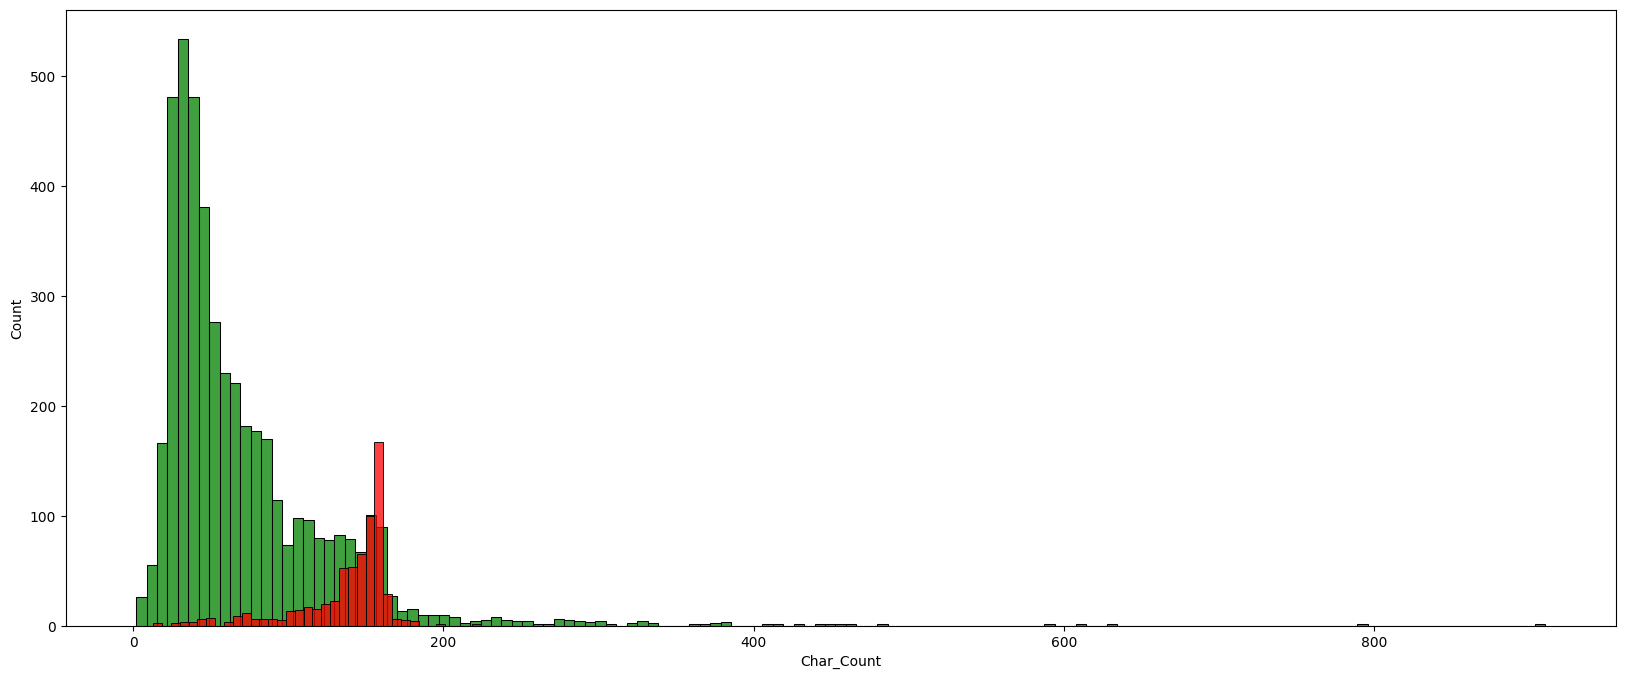

In [34]:
plt.figure(figsize=(20, 8)) 
sns.histplot(dataset[dataset['Type'] == 0]['Char_Count'], color='green')
sns.histplot(dataset[dataset['Type'] == 1]['Char_Count'], color='red')
plt.show()

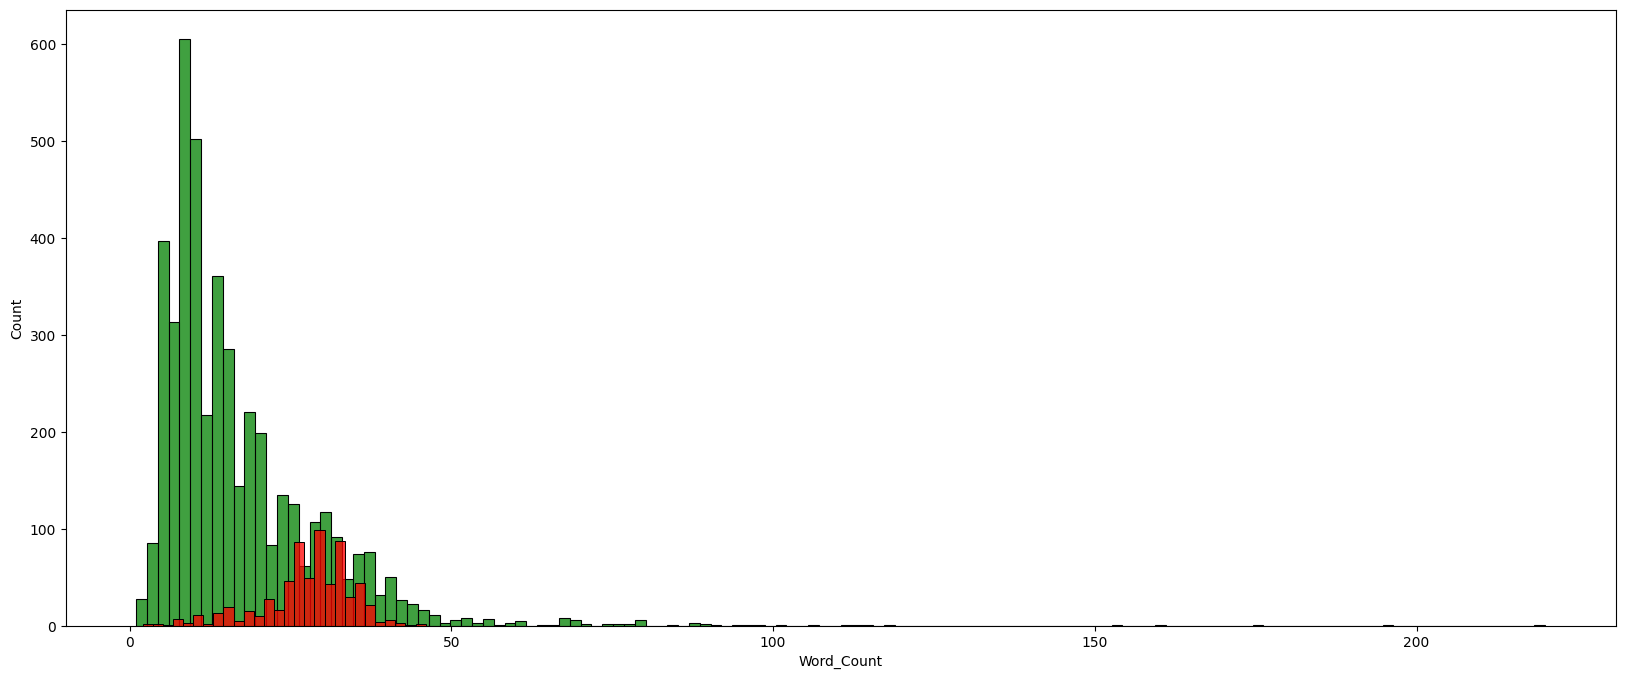

In [35]:
plt.figure(figsize=(20, 8))
sns.histplot(dataset[dataset['Type'] == 0]['Word_Count'], color='green')
sns.histplot(dataset[dataset['Type'] == 1]['Word_Count'], color='red')
plt.show()

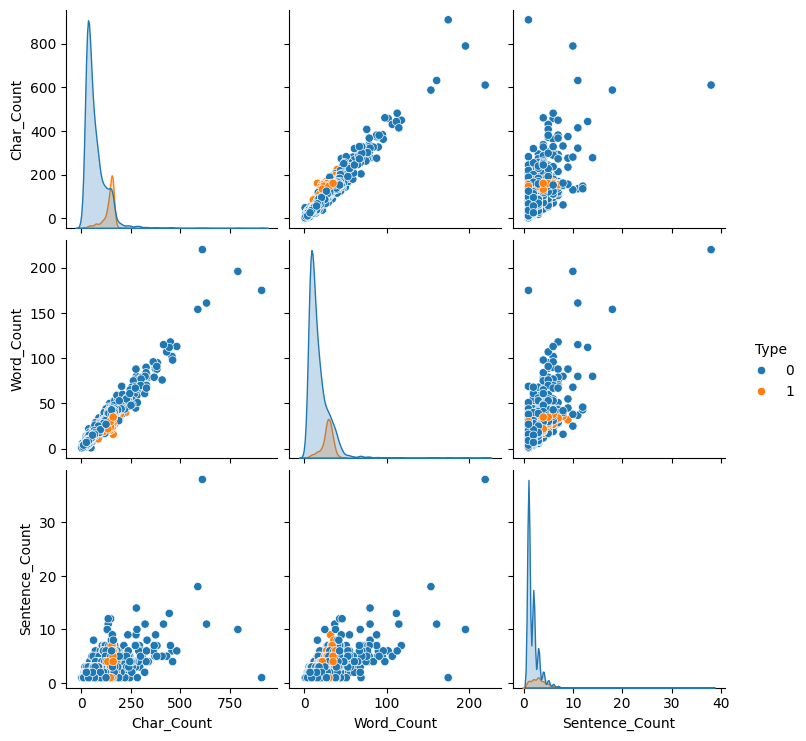

In [36]:
sns.pairplot(dataset, hue='Type')
plt.show()

In [37]:
dataset[['Type', 'Char_Count', 'Word_Count', 'Sentence_Count']].corr()

,Type,Char_Count,Word_Count,Sentence_Count
Type,1.000000,0.384717,0.262912,0.263939
Char_Count,0.384717,1.000000,0.965760,0.624139
Word_Count,0.262912,0.965760,1.000000,0.679971
Sentence_Count,0.263939,0.624139,0.679971,1.000000


<Axes: >

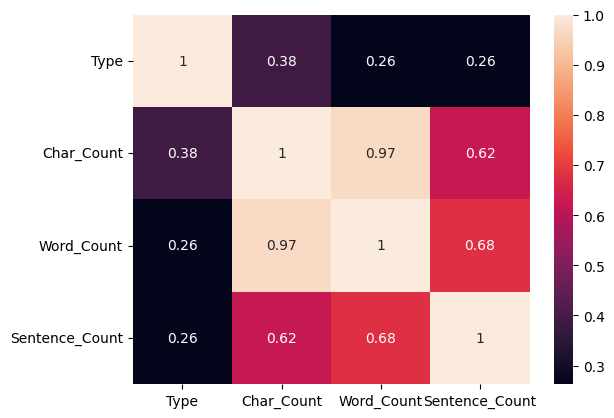

In [38]:
sns.heatmap(dataset[['Type', 'Char_Count', 'Word_Count', 'Sentence_Count']].corr(), annot=True)

## 3. Data Preprocessing (Text Preprocessing)

In [39]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ragnar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [40]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [41]:
import string 
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [42]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [43]:
ps.stem('carrying')

'carri'

In [44]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text) 

    y = []
    for i in text:
        if i.isalnum():
            y.append(i) 

    text = y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation: 
            y.append(i)

    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [45]:
transform_text("hi there Hr. How are you doing today??")

'hi hr today'

In [46]:
transform_text(dataset['message'][1])

'ok lar joke wif u oni'

In [47]:
dataset['message'][1]

'Ok lar... Joking wif u oni...'

In [48]:
dataset['transformed_text'] = dataset['message'].apply(transform_text)

In [49]:
dataset.head()

,Type,message,Char_Count,Word_Count,Sentence_Count,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


### Word Cloud

In [50]:
from wordcloud import WordCloud

In [51]:
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='black')

In [52]:
spam_wc = wc.generate(dataset[dataset['Type'] == 1]['transformed_text'].str.cat(sep=" ")) 

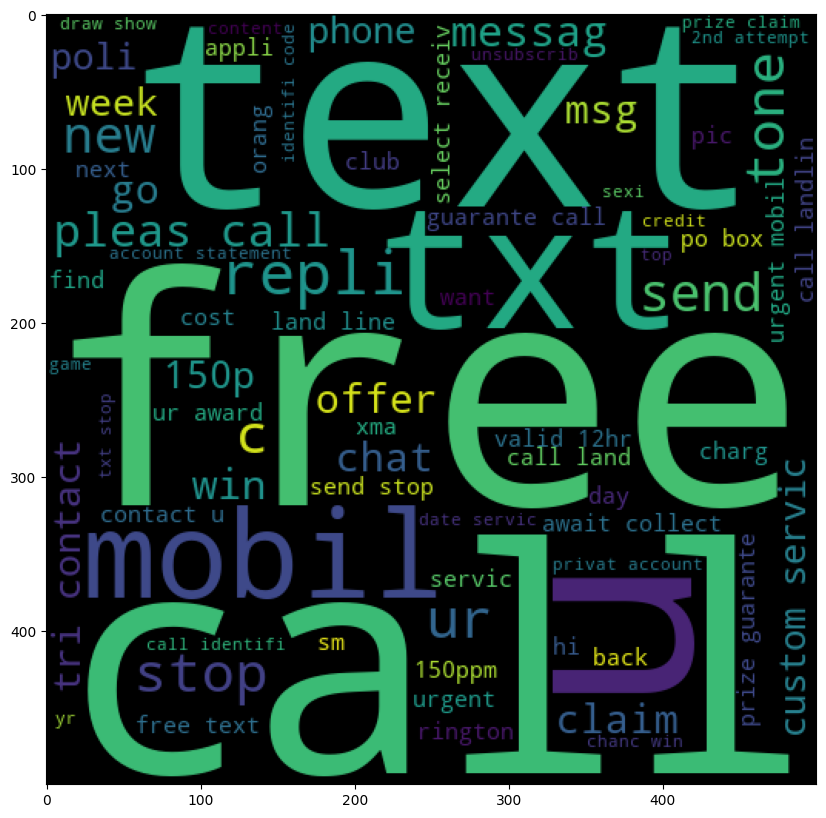

In [53]:
plt.figure(figsize=(10,10))
plt.imshow(spam_wc)
plt.show()

In [54]:
ham_wc = wc.generate(dataset[dataset['Type'] == 0]['transformed_text'].str.cat(sep=" ")) 

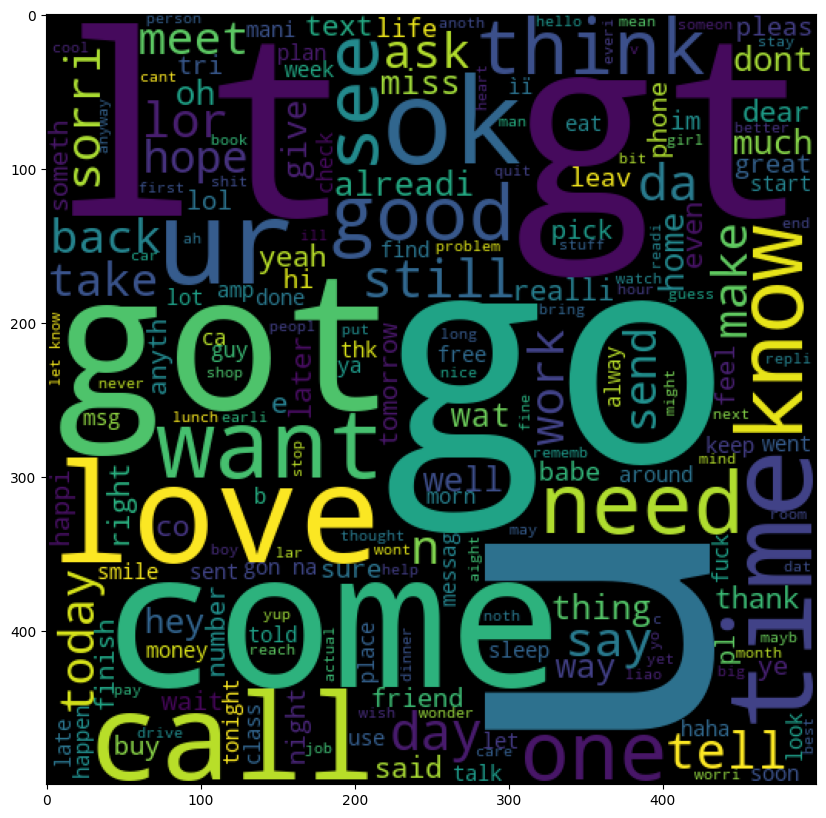

In [55]:
plt.figure(figsize=(10,10))
plt.imshow(ham_wc)
plt.show()

In [56]:
dataset[dataset['Type'] == 1]['transformed_text']

2       free entri 2 wkli comp win fa cup final tkt 21...
5       freemsg hey darl 3 week word back like fun sti...
8       winner valu network custom select receivea pri...
9       mobil 11 month u r entitl updat latest colour ...
11      six chanc win cash 100 pound txt csh11 send co...
                              ...                        
5537    want explicit sex 30 sec ring 02073162414 cost...
5540    ask 3mobil 0870 chatlin inclu free min india c...
5547    contract mobil 11 mnth latest motorola nokia e...
5566    remind o2 get pound free call credit detail gr...
5567    2nd time tri 2 contact u pound prize 2 claim e...
Name: transformed_text, Length: 653, dtype: object

In [57]:
spam_corpus = []
for msg in dataset[dataset['Type'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [58]:
from collections import Counter

In [59]:
len(spam_corpus)

9939

In [60]:
pd.DataFrame(Counter(spam_corpus).most_common(30))

,0,1
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,103


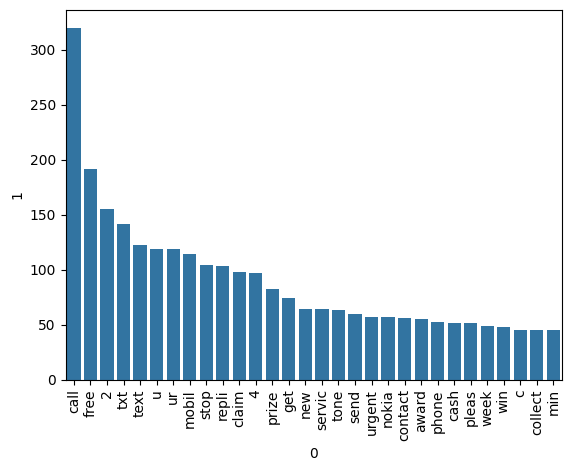

In [61]:
sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30)), x=0, y=1)
plt.xticks(rotation='vertical') # Rotate X axis labels in Vertical Direction
plt.show()

## 4. Model Building

### Count Vectorizer

In [62]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [63]:
cv = CountVectorizer()

In [64]:
X = cv.fit_transform(dataset['transformed_text']).toarray()

In [65]:
Y = dataset['Type'].values

In [66]:
Y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [67]:
from sklearn.model_selection import train_test_split

In [68]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [69]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [70]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [71]:
gnb.fit(x_train, y_train) 
print(gnb.score(x_test, y_test) * 100)
y_prd_gnb = gnb.predict(x_test) 
print(accuracy_score(y_test, y_prd_gnb) * 100)
print(confusion_matrix(y_test, y_prd_gnb))
print(precision_score(y_test, y_prd_gnb) * 100)

88.00773694390716
88.00773694390716
[[792 104]
 [ 20 118]]
53.153153153153156


In [72]:
mnb.fit(x_train, y_train) 
print(mnb.score(x_test, y_test) * 100)
y_prd_mnb = mnb.predict(x_test) 
print(accuracy_score(y_test, y_prd_mnb) * 100)
print(confusion_matrix(y_test, y_prd_mnb))
print(precision_score(y_test, y_prd_mnb) * 100)

96.42166344294004
96.42166344294004
[[871  25]
 [ 12 126]]
83.44370860927152


In [73]:
bnb.fit(x_train, y_train) 
print(bnb.score(x_test, y_test) * 100)
y_prd_bnb = bnb.predict(x_test) 
print(accuracy_score(y_test, y_prd_bnb) * 100)
print(confusion_matrix(y_test, y_prd_bnb))
print(precision_score(y_test, y_prd_bnb) * 100)

97.00193423597679
97.00193423597679
[[893   3]
 [ 28 110]]
97.34513274336283


### TF-IDF Vectorizer

In [74]:
tfv = TfidfVectorizer()

In [75]:
X_tf = tfv.fit_transform(dataset['transformed_text']).toarray()

In [76]:
Y = dataset['Type'].values

In [77]:
Y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [78]:
x_train1, x_test1, y_train1, y_test1 = train_test_split(X_tf, Y, test_size=0.2, random_state=2)

In [79]:
gnb1 = GaussianNB()
mnb1 = MultinomialNB()
bnb1 = BernoulliNB()

In [80]:
gnb1.fit(x_train1, y_train1) 
print(gnb1.score(x_test, y_test) * 100)
y_prd_gnb1 = gnb1.predict(x_test1) 
print(accuracy_score(y_test1, y_prd_gnb1) * 100)
print(confusion_matrix(y_test1, y_prd_gnb1))
print(precision_score(y_test, y_prd_gnb1) * 100)

88.20116054158608
87.62088974854933
[[793 103]
 [ 25 113]]
52.31481481481482


In [81]:
mnb1.fit(x_train1, y_train1) 
print(mnb1.score(x_test1, y_test1) * 100)
y_prd_mnb1 = mnb1.predict(x_test1) 
print(accuracy_score(y_test1, y_prd_mnb1) * 100)
print(confusion_matrix(y_test1, y_prd_mnb1))
print(precision_score(y_test1, y_prd_mnb1) * 100)

95.93810444874275
95.93810444874275
[[896   0]
 [ 42  96]]
100.0


In [82]:
bnb1.fit(x_train1, y_train1) 
print(bnb1.score(x_test1, y_test1) * 100)
y_prd_bnb1 = bnb1.predict(x_test1) 
print(accuracy_score(y_test1, y_prd_bnb1) * 100)
print(confusion_matrix(y_test1, y_prd_bnb1))
print(precision_score(y_test1, y_prd_bnb1) * 100)

97.00193423597679
97.00193423597679
[[893   3]
 [ 28 110]]
97.34513274336283


## Improvement

- TFidf -> MNB(MultinomialNB)

In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC 
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [84]:
svc = SVC(kernel='sigmoid', gamma=1.0) 
knc = KNeighborsClassifier()
mnbc = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1') 
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2) 
bgc = BaggingClassifier(n_estimators=50, random_state=2) 
etc = ExtraTreesClassifier(n_estimators=50, random_state=2) 
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2) 
xgb = XGBClassifier(n_estimators=50, random_state=2) 

In [85]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB' : mnbc, 
    'DT' : dtc, 
    'LR' : lrc, 
    'RF' : rfc, 
    'AdaBoost' : abc, 
    # 'BgC' : bgc, 
    'ETC' : etc, 
    'GradientBoosting': gbdt, 
    'XGBC' : xgb
}

In [86]:
tidf = TfidfVectorizer(max_features=3000) 

In [87]:
x_test_tv = tidf.fit_transform(dataset['transformed_text']).toarray()

In [88]:
xtrain, xtest, ytrain, ytest = train_test_split(x_test_tv, Y, test_size = 0.2, random_state=2)

In [89]:
def train_classifier(clf, x_train, y_train, x_test, y_test):
    clf.fit(x_train, y_train) 
    y_pred = clf.predict(x_test) 
    accuracy = accuracy_score(y_test, y_pred) * 100
    precision = precision_score(y_test, y_pred) * 100

    return accuracy, precision

In [90]:
train_classifier(svc, x_train1, y_train1, x_test1, y_test1)

(97.29206963249516, 97.41379310344827)

In [91]:
accuracy_scores = [] 
precision_scores = [] 

for name, clf in clfs.items():

    current_accuracy, current_precision = train_classifier(clf, x_train1, y_train1, x_test1, y_test1) 

    print('For ', name)
    print('Accuracy', current_accuracy) 
    print('Precision', current_precision) 
    
    accuracy_scores.append(current_accuracy) 
    precision_scores.append(current_precision) 

For  SVC
Accuracy 97.29206963249516
Precision 97.41379310344827
For  KN
Accuracy 90.0386847195358
Precision 100.0
For  NB
Accuracy 95.93810444874275
Precision 100.0
For  DT
Accuracy 93.52030947775629
Precision 83.80952380952381


D:\Program Files\Python3.14\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
D:\Program Files\Python3.14\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For  LR
Accuracy 95.16441005802709
Precision 94.0
For  RF
Accuracy 97.1953578336557
Precision 100.0
For  AdaBoost
Accuracy 92.45647969052224
Precision 84.0909090909091
For  ETC
Accuracy 97.29206963249516
Precision 98.24561403508771
For  GradientBoosting
Accuracy 95.26112185686654
Precision 92.38095238095238
For  XGBC
Accuracy 97.48549323017409
Precision 95.16129032258065


In [92]:
performance_df_accuracy = pd.DataFrame({
    'Algorithms': clfs.keys(),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
}).sort_values('Accuracy', ascending=False)

performance_df_precision = pd.DataFrame({
    'Algorithms': clfs.keys(),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
}).sort_values('Precision', ascending=False)

In [93]:
performance_df_precision

,Algorithms,Accuracy,Precision
1,KN,90.038685,100.000000
2,NB,95.938104,100.000000
5,RF,97.195358,100.000000
7,ETC,97.292070,98.245614
0,SVC,97.292070,97.413793
9,XGBC,97.485493,95.161290
4,LR,95.164410,94.000000
8,GradientBoosting,95.261122,92.380952
6,AdaBoost,92.456480,84.090909
3,DT,93.520309,83.809524


In [94]:
performance_df_accuracy

,Algorithms,Accuracy,Precision
9,XGBC,97.485493,95.161290
0,SVC,97.292070,97.413793
7,ETC,97.292070,98.245614
5,RF,97.195358,100.000000
2,NB,95.938104,100.000000
8,GradientBoosting,95.261122,92.380952
4,LR,95.164410,94.000000
3,DT,93.520309,83.809524
6,AdaBoost,92.456480,84.090909
1,KN,90.038685,100.000000


In [95]:
performance_df_accuracy1 = pd.melt(performance_df_accuracy, id_vars = 'Algorithms')

In [96]:
performance_df_accuracy1

,Algorithms,variable,value
0,XGBC,Accuracy,97.485493
1,SVC,Accuracy,97.292070
2,ETC,Accuracy,97.292070
3,RF,Accuracy,97.195358
4,NB,Accuracy,95.938104
5,GradientBoosting,Accuracy,95.261122
6,LR,Accuracy,95.164410
7,DT,Accuracy,93.520309
8,AdaBoost,Accuracy,92.456480
9,KN,Accuracy,90.038685


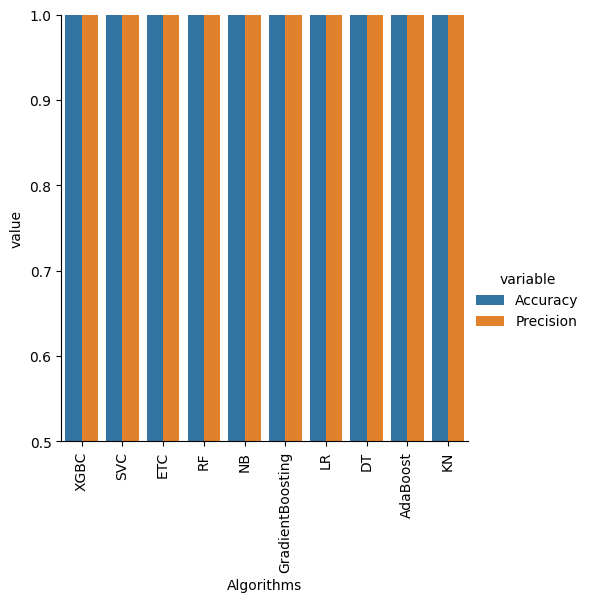

In [99]:
sns.catplot(x = 'Algorithms', y = 'value',
            hue = 'variable', data = performance_df_accuracy1,
            kind = 'bar', height = 5) 
plt.ylim(0.5, 1.0) 
plt.xticks(rotation = 'vertical')
plt.show()

In [101]:
accuracy_with_max_ft = []
precision_with_max_ft = []

for name, clf in clfs.items():

    current_accuracy, current_precision = train_classifier(clf, xtrain, ytrain, xtest, ytest) 

    print('For ', name)
    print('Accuracy_with_Max', current_accuracy) 
    print('Precision_with_Max', current_precision) 
    
    accuracy_with_max_ft.append(current_accuracy) 
    precision_with_max_ft.append(current_precision) 

For  SVC
Accuracy_with_Max 97.58220502901354
Precision_with_Max 97.47899159663865
For  KN
Accuracy_with_Max 90.52224371373308
Precision_with_Max 100.0
For  NB
Accuracy_with_Max 97.09864603481626
Precision_with_Max 100.0
For  DT
Accuracy_with_Max 93.32688588007737
Precision_with_Max 84.15841584158416
For  LR
Accuracy_with_Max 95.55125725338492
Precision_with_Max 96.0


D:\Program Files\Python3.14\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
D:\Program Files\Python3.14\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For  RF
Accuracy_with_Max 97.38878143133462
Precision_with_Max 98.26086956521739
For  AdaBoost
Accuracy_with_Max 92.16634429400386
Precision_with_Max 82.02247191011236
For  ETC
Accuracy_with_Max 97.48549323017409
Precision_with_Max 97.45762711864407
For  GradientBoosting
Accuracy_with_Max 95.06769825918762
Precision_with_Max 93.06930693069307
For  XGBC
Accuracy_with_Max 96.80851063829788
Precision_with_Max 94.87179487179486


In [102]:
temp_df = pd.DataFrame({
    'Algorithms': clfs.keys(),
    'Accuracy_With_Max_Fe': accuracy_with_max_ft,
    'Precision_With_Max_Fe': precision_with_max_ft
})

In [103]:
temp_df

,Algorithms,Accuracy_With_Max_Fe,Precision_With_Max_Fe
0,SVC,97.582205,97.478992
1,KN,90.522244,100.000000
2,NB,97.098646,100.000000
3,DT,93.326886,84.158416
4,LR,95.551257,96.000000
5,RF,97.388781,98.260870
6,AdaBoost,92.166344,82.022472
7,ETC,97.485493,97.457627
8,GradientBoosting,95.067698,93.069307
9,XGBC,96.808511,94.871795


In [104]:
performance_df_precision.merge(temp_df, on='Algorithms')

,Algorithms,Accuracy,Precision,Accuracy_With_Max_Fe,Precision_With_Max_Fe
0,KN,90.038685,100.000000,90.522244,100.000000
1,NB,95.938104,100.000000,97.098646,100.000000
2,RF,97.195358,100.000000,97.388781,98.260870
3,ETC,97.292070,98.245614,97.485493,97.457627
4,SVC,97.292070,97.413793,97.582205,97.478992
5,XGBC,97.485493,95.161290,96.808511,94.871795
6,LR,95.164410,94.000000,95.551257,96.000000
7,GradientBoosting,95.261122,92.380952,95.067698,93.069307
8,AdaBoost,92.456480,84.090909,92.166344,82.022472
9,DT,93.520309,83.809524,93.326886,84.158416


In [105]:
import pickle

In [106]:
pickle.dump(tidf, open('vectorizer.pkl', 'wb'))

In [107]:
pickle.dump(mnbc, open('model.pkl', 'wb'))